In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/constants.py"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [22]:
from matplotlib.ticker import FormatStrFormatter

In [3]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND5/load_band5_data.py"

path = band5_data_folder_path

B5 = BuildBandDictionary(
    path,
    StokesI_wcs,
    xmin,
    xmax,
    ymin,
    ymax,
    reference_length_pix,
    reference_length_AU,
    BMAJ_pix,
    BMIN_pix,
    BPA_deg_cartesian,
    max_length_pix,
    reference_fraction,
    POLI_debiased_mJy, # There is no Band 5 debiased yet,
    StokesI_mJy,
    RA_centre_pix, Dec_centre_pix,
)

stream_vectors_B5 = stream_vectors

band = Band 5
max_str = 'J163135.750-240128.700'
StokesI_wcs CRPIX = [513. 513.]
StokesI_wcs CDELT = [-5.e-06  5.e-06]
Pixel scale = 0.018 arcsec/pixel
Dec_max_pix = 581
 


In [25]:
# ---------------------------------------------------------------------------------------------
def create_stokes_i_plus_one_delta(band, 
                                   data, 
                                   centre_string,
                                   StokesI_wcs, StokesI_stretched, 
                                   normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                                   other_plotting, other_plotting_label, 
                                   soft_colormap_v2, 
#                                    reference_length_AU,
#                                    BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                                   max_length_pix, 
                                   reference_fraction,
                                   text_fs = constants.text_fs , 
                                   axis_label_fs = constants.axis_label_fs, 
                                   axis_num_fs = constants.axis_num_fs, 
                                   cbar_fs = constants.cbar_fs,
                                   label = None,
                                   fontcolor = "black",
                                   fig_x_size = 12, fig_y_size = 6.5,
                                   beam_lw = 1.5,
                                   x_pos = 0.06, 
                                   y_pos = 0.85,
                                   AU100_lw = 2.5, AU100_fs = 20):

#     fig, ax = plt.subplots(1, 2, figsize=(28, 12),
#                            gridspec_kw={'wspace': -0.5},  # Increase wspace for more horizontal space
#                            subplot_kw={'projection': StokesI_wcs})



    # Get the centre position of the disk
    # ---------------------------------------------------
    ra_part = centre_string[1:11]
    dec_part = centre_string[11:]


    ra_string = (ra_part[:2] + 'h' + ra_part[2:4] + 'm' + ra_part[4:] + 's')
    dec_string = (dec_part[:3] + 'd' + dec_part[3:5] + 'm' + dec_part[5:] + 's')


    centre = SkyCoord(ra_string, dec_string, frame='icrs')
    # ---------------------------------------------------

    # Make the figure
    # ---------------------------------------------------
    fig = plt.figure(figsize=(fig_x_size, fig_y_size))
    axes = []
    
    
    
    # Loop over the axes
    # ---------------------------------------------------
    for i in range(2):
    # ---------------------------------------------------
        ax = fig.add_subplot(1, 2, i + 1, projection=data['StokesI_wcs'])
        axes.append(ax)

        offset_frame = SkyOffsetFrame(origin=centre)

        overlay = ax.get_coords_overlay(offset_frame)
        
        
        # Set xmin, xmax, ymin, ymax
        # ---------------------------------------------
        half_size_pix = 1.25 / 0.018

        xmin = data['RA_centre_pix'] - half_size_pix
        xmax = data['RA_centre_pix'] + half_size_pix
        ymin = data['Dec_centre_pix'] - half_size_pix
        ymax = data['Dec_centre_pix'] + half_size_pix
        
        # Set the x and y lims
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        # ---------------------------------------------
        
        
        
        
        # Beam, reference length, wavelength label
        # ---------------------------------------------
        line_x_pos = xmax - 0.04 * (xmax - xmin)
        line_y_pos = ymin - 0.14 * (ymin - ymax)  -10
        
        
        x0 = line_x_pos - data['reference_length_pix']
        x1 = line_x_pos
        
        x_mid_data = (x0 + x1) / 2
        y_mid_data = line_y_pos
        
        display_coords = ax.transData.transform((x_mid_data, y_mid_data))
        axes_coords = ax.transAxes.inverted().transform(display_coords)

        x_axes, y_axes = axes_coords
        # ---------------------------------------------
        
        
        ax.plot([x0, x1], [line_y_pos, line_y_pos], color='black', linewidth=AU100_lw)
        
        
        ax.text(
                x_axes,
                y_axes + 0.015,
                f"{data['reference_length_AU']} AU",
                transform=ax.transAxes,
                fontsize=AU100_fs,
                ha='center',
                va='bottom'
            )
        # ---------------------------------------------
        beam_x_pos = xmin - 0.1 * (xmin - xmax)
        beam_y_pos = ymin - 0.1 * (ymin - ymax)
        

        beam = Ellipse((beam_x_pos, beam_y_pos), 
                       width=data['BMAJ_pix'], 
                       height=data['BMIN_pix'],  
                       angle=data['BPA_deg_cartesian'],
                       edgecolor='black', 
                       facecolor='none', 
                       alpha=1, 
                       lw=beam_lw)
        
        ax.add_patch(beam)
        # ---------------------------------------------
        add_band_label(ax, 
                       band, 
                       label, 
                       constants, 
                       x_pos = x_pos, 
                       y_pos = y_pos, 
                       label_fs = 25, 
                       va = 'bottom')
        
        
        
        # ---------------------------------------------
        
        
        
        # Format axes
        # ---------------------------------------------
        for j in range(2):
            ax.coords[j].set_ticks_visible(False)
            ax.coords[j].set_ticklabel_visible(False)
            ax.coords[j].set_axislabel(' ') # This removes default axis labels
            
            overlay[j].set_format_unit(u.arcsec)
            overlay[j].set_axislabel(r' ', fontsize=0)
            overlay[j].set_ticks(spacing=0.8* u.arcsec, direction='in')
            overlay[j].set_ticklabel(size=axis_num_fs)
        
        overlay[0].set_ticks_position('b')
        overlay[0].set_ticklabel_position('b')
        overlay[0].set_axislabel_position('b')

        # Put Delta Dec ticks/labels on the left
        overlay[1].set_ticks_position('l')
        overlay[1].set_ticklabel_position('l')
        overlay[1].set_axislabel_position('l')


        if i != 0:
            overlay[1].set_ticklabel_visible(False)
            
        # ---------------------------------------------
    # ---------------------------------------------------
    

    cax0 = inset_axes(axes[0],
                     width="100%",
                     height="6%",
                     loc="upper center",
                     bbox_to_anchor=(0, 0.075, 1, 1),
                     bbox_transform=axes[0].transAxes,
                     borderpad=0)
    
    cax1 = inset_axes(axes[1],
                 width="100%",
                 height="6%",
                 loc="upper center",
                 bbox_to_anchor=(0, 0.075, 1, 1),
                 bbox_transform=axes[1].transAxes,
                 borderpad=0)
        
    im0 = axes[0].imshow(StokesI_stretched, cmap=soft_colormap_v2)
    im1 = axes[1].imshow(other_plotting, cmap=soft_colormap_v2)

    # Colorbar for Stokes I
    cbar0 = plt.colorbar(im0, cax=cax0, orientation='horizontal', shrink=0.4)
    cbar0.set_label(r'Stokes I [mJy beam$^{-1}$]', fontsize=cbar_fs, labelpad=-2)
    cbar0.ax.tick_params(labelsize=axis_num_fs, which='major', length=7, direction="in")
    cbar0.ax.tick_params(which='minor', length=4, direction="in")
    cbar0.set_ticks(normalized_cbar_ticks)
    cbar0.set_ticklabels([f"{val:.1f}" for val in StokesI_unstretched_cbar_ticks])
    cbar0.ax.xaxis.set_ticks_position("top")
    
    # Colorbar for other plot
    cbar1 = plt.colorbar(im1, cax=cax1, orientation='horizontal', shrink=0.4)
    cbar1.set_label(other_plotting_label, fontsize=cbar_fs, labelpad=2)
    cbar1.ax.tick_params(labelsize=axis_num_fs, which='major', length=7, direction="in")
    cbar1.ax.xaxis.set_ticks_position("top")
    
    cbar0.ax.xaxis.set_label_coords(0.5, 4)
    cbar1.ax.xaxis.set_label_coords(0.5, 4)




    fig.supxlabel(
        r"$\Delta$ RA (arcsec)",
        fontsize=constants.axis_label_fs,
        y=0.05
    )

    fig.supylabel(
        r"$\Delta$ Dec (arcsec)",
        fontsize=constants.axis_label_fs,
        x=0.025
    )
    
    fig.subplots_adjust(wspace = 0.1)
    
    return fig, axes

# ---------------------------------------------------------------------------------------------

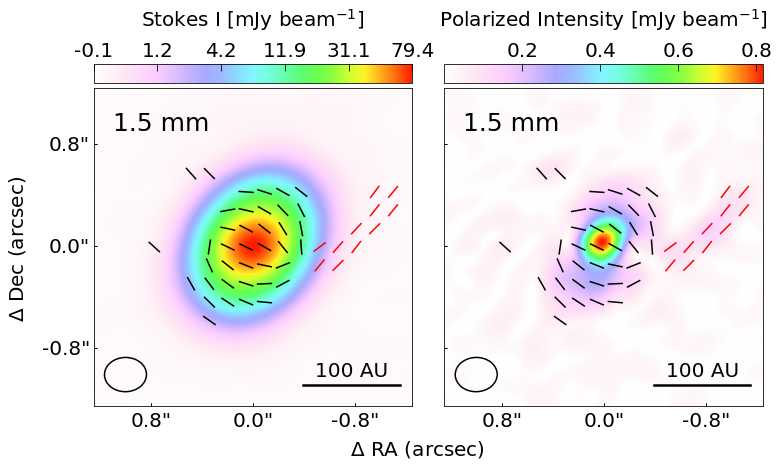

In [27]:
fig, ax = create_stokes_i_plus_one_delta("Band 5", 
                                         B5, 
                                         constants.centre_str_band5, 
                                         StokesI_wcs, StokesI_stretched_mJy, 
                                         normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                                         POLI_debiased_mJy, r'Polarized Intensity [mJy beam$^{-1}$]',
                                         soft_colormap_v2, 
#                                          reference_length_AU,
#                                          BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                                         max_length_pix, reference_fraction, label = 'wavelength')


for i in range(2):
    for row in vector_data_actual_cartesian:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='black')
    
    for row in stream_vectors:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='red')
    

# ax[0].axvline(510, color = 'red')
# ax[0].axvline(520, color = 'blue')
# ax[0].axhline(580, color = 'green')
# ax[0].axhline(520, color = 'orange')

plt.savefig(writeup_image_folder_path + '/StokesI_POLI/'+ "IRS63_StokesI_POLI_vectors_BAND5_delta.png", 
            dpi=300, 
            bbox_inches='tight')    
 